## Assignment Overview

The dataset contains records of car sales, environmental factors, physical measurements, and economic behavior. The analyses are based on data assigned to me for statistical analysis, and are not based on real studies.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy.stats import norm, pearsonr
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.multicomp import pairwise_tukeyhsd

#Loading data
df = pd.read_csv(
    "zadani.csv",
    sep=";",
    decimal=",",
    header=1,
                )

#Separate data for each problem set
df1, df2, df3, df4, df5 = (df.iloc[:, i:i+2] for i in range(0, 10, 2))
dfs = {"df1": df1, "df2": df2, "df3": df3, "df4": df4, "df5": df5}
dfs = {k: v.dropna() for k, v in dfs.items()}
df1, df2, df3, df4, df5 = (dfs[f"df{i}"] for i in range(1, 6))

## Task 1: Car Sales Analysis

Data on car sales from 2024 and 2025 include combustion, hybrid, and electric vehicles.

- Display a table and bar chart of counts by category.
- Estimate a 95% confidence interval for the proportion of electric vehicles in 2025.
- Test whether the proportion of combustion vehicles remained unchanged between 2024 and 2025, against the alternative that it decreased.

In [19]:
#Function for categorizing cars
def categorize_car(car_name):
    car_name = car_name.lower()

#Defining keywords for sorting into categories
    electric = ["tesla", "e-tech"]
    hybrid =["hybrid","c-hr", "superb iv", "kodiaq iv"]
    combustion = ["tdi", "tsi", "hdi", "puretech", "tce", "bluetec", "amg", "330d", "fabia iv"]

#Sorting
    if any(keyword in car_name for keyword in electric):
        return "electric"
    elif any(keyword in car_name for keyword in hybrid):
        return "hybrid"
    elif any(keyword in car_name for keyword in combustion):
        return "combustion"
    else:
        return None



#Applying function to all cars, grouping them and making a sheet
df1["Category2024"] = df1.iloc[:,0].apply(categorize_car)
df1["Category2025"] = df1.iloc[:,1].apply(categorize_car)
counts_2024 = df1.groupby("Category2024").size()
counts_2025 = df1.groupby("Category2025").size()

sheet = pd.concat(
    [
        df1["Category2024"].value_counts().rename("2024"),
        df1["Category2025"].value_counts().rename("2025")
    ],
    axis=1,
    ).fillna(0).astype(int)
sheet.loc["total"] = sheet.sum()

print("This is the sample of 2024 and 2025 data of car powertrain types\n")
print(sheet)


This is the sample of 2024 and 2025 data of car powertrain types

            2024  2025
combustion   724   721
hybrid       356   375
electric     134   118
total       1214  1214


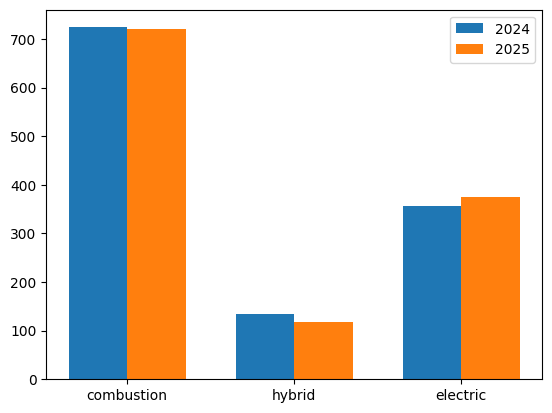

In [20]:
#Plotting the data
labels = ["combustion", "hybrid", "electric"]
width = 0.35
pos = np.arange(len(labels))

plt.bar(pos - width/2 ,counts_2024, width=width, label="2024")
plt.bar(pos + width/2,counts_2025, width=width, label="2025")
plt.xticks(pos, labels)
plt.legend()
plt.show()


In [21]:
#Testing the confidence interval for the proportion of electric-only cars in the year 2025 with confidence = 95%
electric_2025 = sheet.loc["electric", "2025"]
total_2025 = sheet.loc["total", "2025"]
confidence = 0.95

#Calculating the interval
lower, upper = proportion_confint(
    count = electric_2025,
    nobs = total_2025,
    alpha = 1-confidence,
    method="wilson"                 #Wilson method highly recommended for accuracy
)

print( f"\nRatio of electric cars against the total number of cars in our sample with 95% "
       f"certainty is: <{lower:.4f}; {upper:.4f}>, "
       f"that translates to: <{lower:.2%}; {upper:.2%}>")



Ratio of electric cars against the total number of cars in our sample with 95% certainty is: <0.0818; 0.1152>, that translates to: <8.18%; 11.52%>


In [22]:
#Testing hypothesis, that proportion of combustion cars in 2024 and 2025 is the same
observed = sheet.iloc[0:3,0:2].to_numpy()

#Chi squared hypothesis test
chi2, p, dof, expected = stats.chi2_contingency(observed)
print(f"the chi squared value is : {chi2:.3f}\n")
print(f"the p-value value is : {p:.3f}\n")
print(f"the dof value is :{dof}\n")
print(f"expected values are :\n {expected}\n")
if p>0.05:
    print("We have enough evidence to assume that the proportion of combustion cars in 2024 is the same as in 2025")
else:
    print("We don't have enough evidence to assume that the proportion of combustion cars in 2024 is the same as in 2025")


the chi squared value is : 1.516

the p-value value is : 0.469

the dof value is :2

expected values are :
 [[722.5 722.5]
 [365.5 365.5]
 [126.  126. ]]

We have enough evidence to assume that the proportion of combustion cars in 2024 is the same as in 2025


## Task 2: Temperature vs Beverage Sales

The dataset contains daily temperature and revenue from hot beverages.

- Test whether temperature and revenue are independent.
- Test whether the correlation between temperature and revenue is not positive.

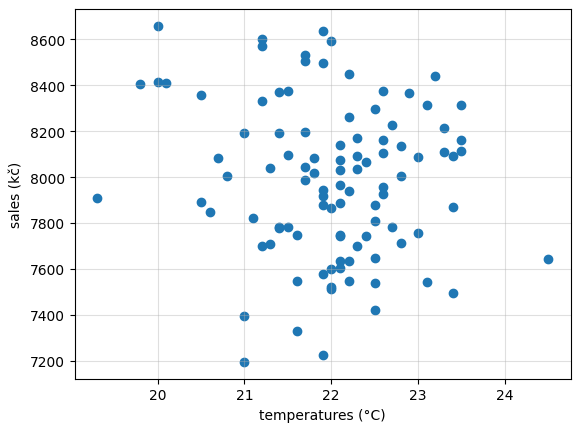

In [23]:
#Cleaning data
df2 = df2.iloc[0:100, :]

#Define variables (to numeric for error prevention)
temperatures = pd.to_numeric(df2.iloc[:, 0], errors='coerce')
sales = pd.to_numeric(df2.iloc[:,1], errors='coerce')

#Scatter plot for temperature and sales
plt.scatter(temperatures, sales)
plt.ylabel("sales (kč)")
plt.xlabel("temperatures (°C)")
plt.grid(True,alpha=0.4)
plt.show()

In [24]:
# Null hypothesis = no correlation between the ambient temperature and sales of hot beverages

#Pearson test for first hypothesis (no correlation)
pearson1 = pearsonr(temperatures, sales)
print("We try the null hypothesis, which says, that there is no correlation between temperatures and sales of hot beverages, we will do this with the pearson correlation test\n")
print(f"the correlation value is: {pearson1.statistic:.3f}\n")
print(f"the p-value value is: {pearson1.pvalue:.3f}\n")
if pearson1.pvalue < 0.05:
    print(f"We decline the null hypothesis, there is substantial evidence for correlation in temperatures and sales of hot beverages and the correlation value is : {pearson1.statistic:.3f}")
else:
    print(f"We accept the null hypothesis, there is not enough evidence for correlation in temperatures and sales of hot beverages")


We try the null hypothesis, which says, that there is no correlation between temperatures and sales of hot beverages, we will do this with the pearson correlation test

the correlation value is: -0.127

the p-value value is: 0.206

We accept the null hypothesis, there is not enough evidence for correlation in temperatures and sales of hot beverages


In [25]:
#Now, we will try to test the hypothesis, that there is negative correlation

#Pearson test for second hypothesis (negative correlation)
pearson2 = pearsonr(temperatures, sales, alternative = "less") # correlation coefficient < 0

print("We try the null hypothesis, which says, that the correlation between ambient temperatures and hot beverage sales is negative\n")
print(f"the correlation value is: {pearson2.statistic:.3f}\n")
print(f"the p-value value is: {pearson2.pvalue:.3f}\n")

if pearson2.pvalue < 0.05:
    print(f"We decline the null hypothesis, there is substantial evidence that there is a positive correlation between the ambient temperature and the sales of hot beverages {pearson2.statistic:.3f}")
else:
    print(f"We accept the null hypothesis, there is substantial evidence that there is a negative correlation between the ambient temperature and the sales of hot beverages and its value is : {pearson2.statistic:.3f}")

We try the null hypothesis, which says, that the correlation between ambient temperatures and hot beverage sales is negative

the correlation value is: -0.127

the p-value value is: 0.103

We accept the null hypothesis, there is substantial evidence that there is a negative correlation between the ambient temperature and the sales of hot beverages and its value is : -0.127


## Task 3: Arm Span vs Height

The dataset includes arm span and body height measurements.

- Test whether arm span is equal to body height, against the alternative that they differ.

In [26]:
#Define variables and difference between each element from dataframes
height = pd.to_numeric(df3.iloc[0:50,0], errors="coerce")
armspan = pd.to_numeric(df3.iloc[0:50,1], errors="coerce")
diff = [a - b for a,b in zip(height, armspan)]

#Shapiro test for normality
shapiro = stats.shapiro(diff)

print(f"The value of Shapiro - Wilk test statistic is: W = {shapiro.statistic:.3f}")
print(f"The p value for this test is: p =  {shapiro.pvalue:.3f}\n")

if shapiro.pvalue < 0.05:
    print("The p value is below 5%, we will reject normality in our samples, we will use a non-parametric test")
else :
   print(f"The p value is above 5%, we will accept normality in our samples with Shapiro-Wilk value W = {shapiro.statistic:.3f} and use the paired t-test\n")

ttest_1 = stats.ttest_rel(height, armspan, alternative="two-sided") #null hypothesis = no difference
print(f"The value of t is: t = {ttest_1.statistic:.3f}")
print(f"The value of p is: p = {ttest_1.pvalue:.3f}\n")

if p<0.05:
    print("The null hypothesis, that the means of our samples are same was rejected")
else:
    print("The null hypothesis, that the means of our samples are same was accepted")

The value of Shapiro - Wilk test statistic is: W = 0.966
The p value for this test is: p =  0.159

The p value is above 5%, we will accept normality in our samples with Shapiro-Wilk value W = 0.966 and use the paired t-test

The value of t is: t = -2.708
The value of p is: p = 0.009

The null hypothesis, that the means of our samples are same was accepted


## Task 4: Engine Performance Decline

Performance loss after 100,000 km was measured for two manufacturers (A and B).

- Compute point estimates (mean, variance, standard deviation) and visualize with boxplots.
- For manufacturer A, test normality and compute confidence intervals (95% and 99%).
- Test whether there is a significant difference between manufacturers A and B.

The mean of loss of power in company A in 100 000 km is 10.049 kW

The mean of loss of power in company B in 100 000 km is 11.733 kW



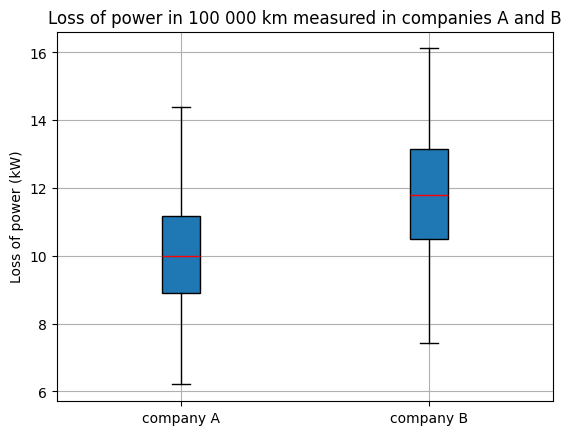

In [27]:
#define variables
company_B = pd.to_numeric(df4.iloc[0:55,1], errors="coerce")
company_A = pd.to_numeric(df4.iloc[0:70,0], errors="coerce")

#Calculating the mean:
mean_A = np.mean(company_A)
mean_B = np.mean(company_B)
print(f"The mean of loss of power in company A in 100 000 km is {mean_A:.3f} kW\n")
print(f"The mean of loss of power in company B in 100 000 km is {mean_B:.3f} kW\n")

#Calculating the standard deviation
std_A = np.std(company_A,ddof=1)   #ddof = 1,  set degrees of freedom = 1
std_B = np.std(company_B,ddof=1)
var_A = np.var(company_A,ddof=1)
var_B = np.var(company_B,ddof=1)

#Plot
plt.style.use("default")
fig, axes = plt.subplots(facecolor="white");
axes.boxplot([company_A,company_B],tick_labels=["company A", "company B"], patch_artist=True, medianprops=dict(color="red"));
axes.set_title("Loss of power in 100 000 km measured in companies A and B");
axes.set_ylabel("Loss of power (kW)");
axes.grid(True);



In [28]:
normal_A, pvalue_A = stats.shapiro(company_A)
print(f"The Shapiro-Wilk test for company A sample showed normality value of: {normal_A:.3f}")
print(f"The p value for this test is: {pvalue_A:.3f}")
if pvalue_A < 0.05:
    print("Data sample for company A shows significant departure from normality")
else:
    print("Data sample for company A does not show significant departure from normality\n")

normal_B, pvalue_B = stats.shapiro(company_B)
print(f"The Shapiro-Wilk test for company B sample showed normality value of: {normal_B:.3f}")
print(f"The p value for this test is: {pvalue_B:.3f}")
if pvalue_B < 0.05:
    print("Data sample for company B shows significant departure from normality")
else:
    print("Data sample for company B does not show significant departure from normality")



The Shapiro-Wilk test for company A sample showed normality value of: 0.984
The p value for this test is: 0.650
Data sample for company A does not show significant departure from normality

The Shapiro-Wilk test for company B sample showed normality value of: 0.985
The p value for this test is: 0.700
Data sample for company B does not show significant departure from normality


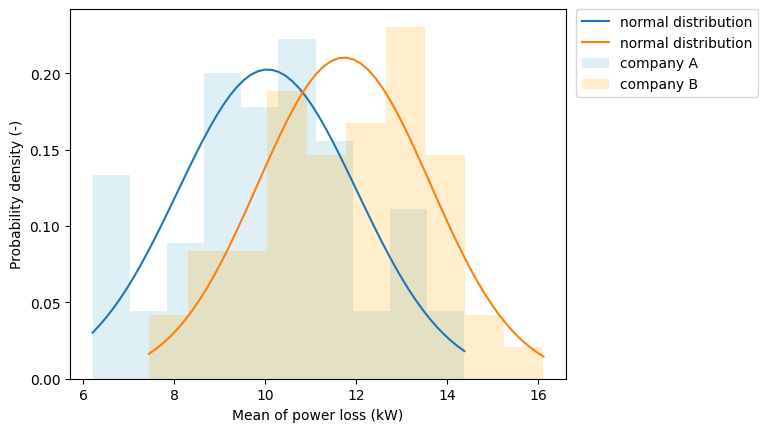

In [29]:
#X values array
x_A = np.linspace(min(company_A), max(company_A), len(company_A))
x_B = np.linspace(min(company_B), max(company_B), len(company_B))

#Means of companies
mu_A = np.mean(company_A)
mu_B = np.mean(company_B)

#Standard deviations for companies
sigma_A = np.std(company_A)
sigma_B = np.std(company_B)

#Plotting values
plt.plot(x_A, norm.pdf(x_A,mu_A, sigma_A), label="normal distribution")
plt.plot(x_B, norm.pdf(x_B,mu_B, sigma_B), label="normal distribution")
plt.hist(company_A,alpha=0.4, label="company A", density=True, color="lightblue")
plt.hist(company_B,alpha=0.2, label="company B", density=True,color="orange")

plt.ylabel("Probability density (-)")
plt.xlabel("Mean of power loss (kW)")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.);




In [30]:
#Calculating standard error of the mean
sem_A = stats.sem(company_A)
sem_B = stats.sem(company_B)

n_A = len(company_A)
n_B = len(company_B)

#Interval of mean, 95% confidence
mu_A_min_95, mu_A_max_95 = stats.t.interval(confidence = 0.95,df=n_A-1,loc=mu_A, scale = sem_A )
mu_B_min_95, mu_B_max_95 = stats.t.interval(confidence = 0.95,df=n_B-1,loc=mu_B, scale = sem_B )
print(f"The mean of company A with certainty 95% is in interval : ({mu_A_min_95} , {mu_A_max_95})")
print(f"The mean of company B with certainty 95% is in interval : ({mu_B_min_95} , {mu_B_max_95})")

#Interval of mean, 99% confidence
mu_A_min_99, mu_A_max_99 = stats.t.interval(confidence = 0.99,df=n_A-1,loc=mu_A, scale = sem_A )
mu_B_min_99, mu_B_max_99 = stats.t.interval(confidence = 0.99,df=n_B-1,loc=mu_B, scale = sem_B )
print(f"The mean of company A with certainty 99% is in interval : ({mu_A_min_99} , {mu_A_max_99})")
print(f"The mean of company B with certainty 99% is in interval : ({mu_B_min_99} , {mu_B_max_99})")


The mean of company A with certainty 95% is in interval : (9.511319189029024 , 10.586171720061884)
The mean of company B with certainty 95% is in interval : (11.215954232765402 , 12.25073667632551)
The mean of company A with certainty 99% is in interval : (9.333031562835652 , 10.764459346255256)
The mean of company B with certainty 99% is in interval : (11.044313100458975 , 12.422377808631936)


In [31]:
ttest_2, pvalue_6 = stats.ttest_ind(company_A, company_B)
if ttest_2 < 0.05:
    print("Our test suggests, that the means of company A and company B in loss of power are not the same")
else:
    print("Our test suggests, that the means of company A and company B in loss of power are the same")

Our test suggests, that the means of company A and company B in loss of power are not the same


## Task 5: Tips in Pubs

The dataset contains tip amounts in different pubs.

- Test whether the type of pub affects tip amount (ANOVA).
- If differences exist, identify which pubs differ significantly.

In [32]:
df5["spropitné [Kč] "] = pd.to_numeric(df5["spropitné [Kč] "].dropna())

# Aggregate tip data by pub
count_pubs = (df5
              .groupby("hospoda")["spropitné [Kč] "]
              .agg(["sum","mean","count"])
              .sort_values("mean", ascending=False).dropna()
              )

print(count_pubs)


                              sum       mean  count
hospoda                                            
Axiom Pub                  2034.0  23.651163     86
Restaurace Kanas Brno      1939.0  23.646341     82
Hostinec U Semináru        2095.0  23.277778     90
Výčep Na stojáka           1564.0  20.051282     78
Pivnice U Kocourka         1723.0  20.034884     86
Hospůdka u Štýblů          1803.0  19.813187     91
Stopkova plzeňská pivnice  1713.0  19.689655     87


In [33]:
# Split tip data into separate groups by pub for statistical analysis (ANOVA)
groups = [
    group.to_numpy()
    for _, group in df5.groupby("hospoda")["spropitné [Kč] "]
]

#ANOVA test (tests significance of difference of means)
f_stats, pvalue_5 = stats.f_oneway(*groups)
print(f"The f value of out test is {f_stats} and the p value is {pvalue_5}")


The f value of out test is 13.527199119644193 and the p value is 2.050187909577234e-14


In [34]:
if pvalue_5 < 0.05:
    print("There is a statisticallly significant difference between the means of all pubs")
else:
    print("We dont see evidence of difference between the means of all pubs ")

There is a statisticallly significant difference between the means of all pubs


In [35]:

# Perform Tukey HSD test to identify which pubs differ in average tip amounts
tukey = pairwise_tukeyhsd(
    endog=df5["spropitné [Kč] "],
    groups=df5["hospoda"],
    alpha=0.05,
)
print(tukey)

                   Multiple Comparison of Means - Tukey HSD, FWER=0.05                    
          group1                    group2          meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------------------------
                Axiom Pub         Hospůdka u Štýblů   -3.838    0.0 -6.0195 -1.6565   True
                Axiom Pub       Hostinec U Semináru  -0.3734 0.9988 -2.5607   1.814  False
                Axiom Pub        Pivnice U Kocourka  -3.6163    0.0 -5.8284 -1.4042   True
                Axiom Pub     Restaurace Kanas Brno  -0.0048    1.0 -2.2437  2.2341  False
                Axiom Pub Stopkova plzeňská pivnice  -3.9615    0.0 -6.1672 -1.7558   True
                Axiom Pub          Výčep Na stojáka  -3.5999 0.0001  -5.868 -1.3318   True
        Hospůdka u Štýblů       Hostinec U Semináru   3.4646 0.0001  1.3082   5.621   True
        Hospůdka u Štýblů        Pivnice U Kocourka   0.2217 0.9999 -1.9598  2.4032  False

In [35]:
#In the ANOVA test, we see which combinations of 2 pubs we can reject or accept the null hypothesis, which is sayig that the means of the given pubs are the same